In [1]:
import argparse

import numpy as np
import pandas as pd

import scipy.interpolate

import h5py

import matplotlib.pyplot as plt
import matplotlib.colors as colors

## Helping function

In [2]:
import argparse

def state_vars(num_mats=2):
    base_vars = {
        'rl': 0,   # lower x edge
        'rh': 1,   # upper x edge
        'zl': 2,   # lower y edge
        'zh': 3,   # upper y edge
        'vol': 4,  # cell volume
        'den': 5,  # den (kg/m3)
    }
    
    start_index_mats = 22 # Modifié suite à la vérification HDFView
    
    materials = []
    for i in range(num_mats):
        # fvol 1 est à 22, fvol 2 est à 23
        idx_f = start_index_mats + i      
        # fvrho 1 est à 24, fvrho 2 est à 25 (décalage de num_mats)
        idx_fr = start_index_mats + num_mats + i  
        
        mat_namespace = argparse.Namespace(f=idx_f, fr=idx_fr)
        materials.append(mat_namespace)
        
    base_vars['ms'] = materials
    return argparse.Namespace(**base_vars)

In [3]:
units = argparse.Namespace(
  s_to_ns=1e9, 
  m_to_nm=1e9, 
  kg_to_g=1e3, 
  m3_to_l=1e3
)

In [4]:
file_name = 'dd_target_state.h5'

In [5]:
h5f = h5py.File(file_name, 'r')
print(h5f.keys())

<KeysViewHDF5 ['box_fine_cy000000', 'box_fine_cy000001', 'box_fine_cy000002', 'box_fine_cy000003', 'box_fine_cy000004', 'box_fine_cy000005', 'box_fine_cy000006', 'box_fine_cy000007', 'box_fine_cy000008', 'box_fine_cy000009', 'box_fine_cy000010', 'box_fine_cy000011', 'box_fine_cy000012', 'box_fine_cy000013', 'box_fine_cy000014', 'box_fine_cy000015', 'box_fine_cy000016', 'box_fine_cy000017', 'box_fine_cy000018', 'box_fine_cy000019', 'box_fine_cy000020', 'box_fine_cy000021', 'box_fine_cy000022', 'box_fine_cy000023', 'box_fine_cy000024', 'box_fine_cy000025', 'box_fine_cy000026', 'box_fine_cy000027', 'box_fine_cy000028', 'box_fine_cy000029', 'box_fine_cy000030', 'box_fine_cy000031', 'box_fine_cy000032', 'box_fine_cy000033', 'box_fine_cy000034', 'box_fine_cy000035', 'box_fine_cy000036', 'box_fine_cy000037', 'box_fine_cy000038', 'box_fine_cy000039', 'box_fine_cy000040', 'box_fine_cy000041', 'box_fine_cy000042', 'box_fine_cy000043', 'box_fine_cy000044', 'box_fine_cy000045', 'box_fine_cy000046'

In [6]:
def get_time(ds):
  time = float(ds.attrs['time'][0])
  return time

In [7]:
items = []

for ds_name in h5f.keys():

  ds = h5f[ds_name]
  time = get_time(ds)

  num_mats = 2
  js = state_vars(num_mats)

  rl, rh = ds[:,:,js.rl], ds[:,:,js.rh]
  zl, zh = ds[:,:,js.zl], ds[:,:,js.zh]

  rc, zc = 0.5*(rl+rh), 0.5*(zl+zh)

  vol = ds[:,:,js.vol]

  den = ds[:,:,js.den]

  f1, f2 = ds[:,:,js.ms[0].f], ds[:,:,js.ms[1].f]
  fr1, fr2 = ds[:,:,js.ms[0].fr], ds[:,:,js.ms[1].fr]

  items.append({
    'time': time,
    'm1': np.sum(fr1 * vol),
    'v1': np.sum(f1*vol),
    'm2': np.sum(fr2 * vol),
    'v2': np.sum(f2*vol),
  })

items = pd.DataFrame(items)

In [8]:
items['d1'] = items['m1'] / items['v1']
items['d2'] = items['m2'] / items['v2']

Text(0, 0.5, 'Mass (kg)')

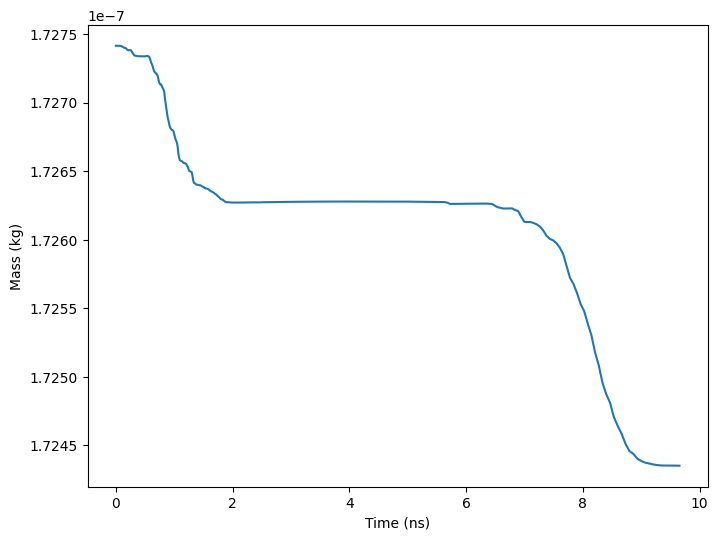

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(items['time']*units.s_to_ns, items['m1'], label='d1')
ax.set_xlabel(r'Time (ns)')
ax.set_ylabel(r'Mass (kg)')

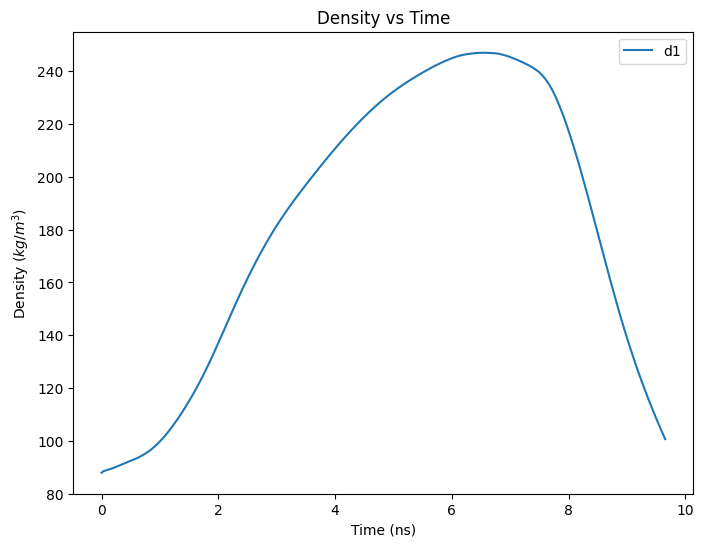

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(items['time']*units.s_to_ns, items['d1'], label='d1')
ax.set_xlabel(r'Time (ns)')
ax.set_ylabel(r'Density ($kg/m^3$)')
ax.set_title('Density vs Time')
ax.legend()

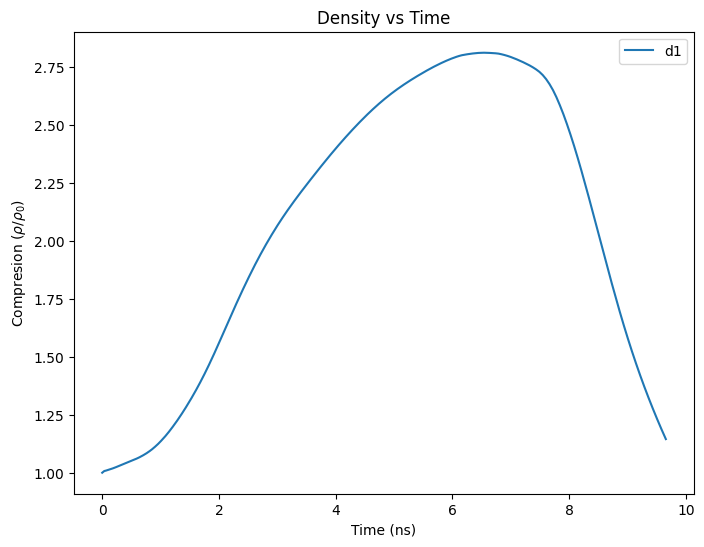

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

den_ref = items['d1'][0]

ax.plot(items['time']*units.s_to_ns, items['d1']/den_ref, label='d1')
ax.set_xlabel(r'Time (ns)')
ax.set_ylabel(r'Compresion ($\rho/\rho_0$)')
ax.set_title('Density vs Time')
ax.legend()

In [12]:
ds_name = 'box_fine_cy000248'

ds = h5f[ds_name]

num_mats = 2
js = state_vars(num_mats)

In [13]:
rl, rh = ds[:,:,js.rl], ds[:,:,js.rh]
zl, zh = ds[:,:,js.zl], ds[:,:,js.zh]

rc, zc = 0.5*(rl+rh), 0.5*(zl+zh)

vol = ds[:,:,js.vol]

den = ds[:,:,js.den]


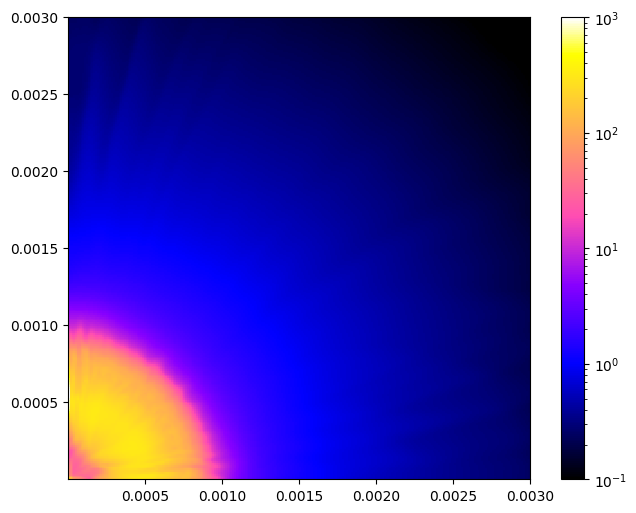

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.set_aspect('equal')
im = ax.pcolormesh(rc, zc, den, cmap='gnuplot2', shading='auto', norm=colors.LogNorm(vmin = 0.1, vmax = 1000))
cb = fig.colorbar(im, ax=ax)

In [15]:
rs = np.linspace(0, 2.e-3, 100)
ts = np.linspace(0, np.pi/2, 100)

list_steps = []
for ds_name in h5f.keys():
  
  ds = h5f[ds_name]
  time = get_time(ds)

  num_mats = 2
  js = state_vars(num_mats)

  rl, rh = ds[:,:,js.rl], ds[:,:,js.rh]
  zl, zh = ds[:,:,js.zl], ds[:,:,js.zh]

  rc, zc = 0.5*(rl+rh), 0.5*(zl+zh)

  vol = ds[:,:,js.vol]
  den = ds[:,:,js.den]

  # Extraction des coordonnées uniques pour l'interpolateur (Scipy adore ça)
  rc_axis = np.unique(rc)
  zc_axis = np.unique(zc)

  func_den = scipy.interpolate.RegularGridInterpolator(
    (rc_axis, zc_axis), 
    den, 
    bounds_error=False, 
    fill_value=None
  )

  step = []
  for ri in rs:
    zs = ri * np.cos(ts)
    xs = ri * np.sin(ts)
    
    # SOLUTION : On combine xs et zs en un tableau de points (N, 2)
    points_to_interpolate = np.column_stack((xs, zs))
    
    # On passe ce tableau unique à l'interpolateur
    den_interpolated = func_den(points_to_interpolate)

    sx = np.sum(xs)
    d  = np.sum(den_interpolated * xs) / sx
    d2 = np.sum(den_interpolated**2 * xs) / sx

    step.append((d, d2))
  
  list_steps.append((time, np.array(step)))


C:\Users\clara\AppData\Local\Temp\ipykernel_13772\2508478672.py:44: RuntimeWarning: invalid value encountered in scalar divide
  d  = np.sum(den_interpolated * xs) / sx
C:\Users\clara\AppData\Local\Temp\ipykernel_13772\2508478672.py:45: RuntimeWarning: invalid value encountered in scalar divide
  d2 = np.sum(den_interpolated**2 * xs) / sx


## Graph

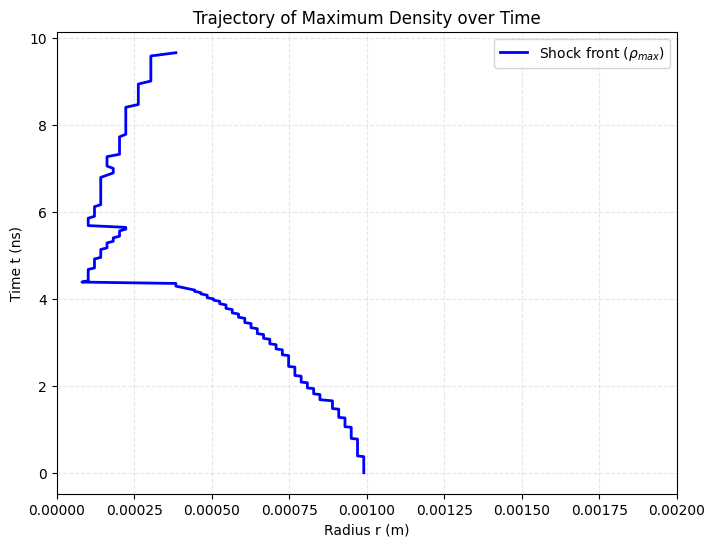

In [ ]:
rs = np.linspace(0, 2.e-3, 100)
ts = np.linspace(0, np.pi/2, 100)

times_list = []
radius_of_max_density = []

# Loop to analyze each time step
for ds_name in h5f.keys():
  ds = h5f[ds_name]
  time = get_time(ds)
  
  num_mats = 2
  js = state_vars(num_mats)

  rl, rh = ds[:,:,js.rl], ds[:,:,js.rh]
  zl, zh = ds[:,:,js.zl], ds[:,:,js.zh]
  rc, zc = 0.5*(rl+rh), 0.5*(zl+zh)
  den = ds[:,:,js.den]

  rc_axis = np.unique(rc)
  zc_axis = np.unique(zc)

  func_den = scipy.interpolate.RegularGridInterpolator(
    (rc_axis, zc_axis), 
    den, 
    bounds_error=False, 
    fill_value=0.0
  )

  step_density = []
  for ri in rs:
    zs = ri * np.cos(ts)
    xs = ri * np.sin(ts)
    
    points_to_interpolate = np.column_stack((xs, zs))
    den_interpolated = func_den(points_to_interpolate)

    sx = np.sum(xs)
    d = np.sum(den_interpolated * xs) / sx if sx > 0 else 0
    step_density.append(d)
  
  step_density = np.array(step_density)
  
  # STRATEGY: Find the index of the radius where the density is the highest
  idx_max = np.argmax(step_density)
  r_max = rs[idx_max]
  
  # Only keep the point if it is in the physical zone (non-zero density)
  if step_density[idx_max] > 1.0: 
    times_list.append(time * units.s_to_ns) # Time in ns
    radius_of_max_density.append(r_max)


fig, ax = plt.subplots(1, 1, figsize=(8, 6))


ax.plot(radius_of_max_density, times_list, 'b-', linewidth=2, label=r'Shock front ($\rho_{max}$)')


ax.set_xlabel('Radius r (m)')
ax.set_ylabel('Time t (ns)')
ax.set_title('Trajectory of Maximum Density over Time')

ax.set_xlim(0, 2.e-3)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.show()